# Exploratory Data Analysis - EDA

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

CARGAR DATOS

In [2]:
data_path = r"dataset_original.xlsx"

In [3]:
#cargar dataset
df = pd.read_excel(data_path, header=0)
#mostrar las primeras filas del dataset
df.head()

,IDALUMNE,IDCURS,IDEVALUACIO,MATERIA,RESULT,TOTAL,POBLACIO,DATANAIXEMENT,SEXO,TIPUS_ESCOLA,DATA,DESCRIPCIO,PROFE,TIPOESTUDIANTS,EJERCICIO_ESCOLAR,INICI
0,30,788,53,LISTENING,18.8,68.3,Barcelona,1998-10-30,F,PUBLICA,2015-06-20,TERCER TRIMESTRE,GUY,TEENS,Curs 2014-2015,2014-09-15
1,30,788,50,GRAMMAR,10.2,64.9,Barcelona,1998-10-30,F,PUBLICA,2014-12-23,PRIMER TRIMESTRE,GUY,TEENS,Curs 2014-2015,2014-09-15
2,30,788,53,WRITING,14.5,68.3,Barcelona,1998-10-30,F,PUBLICA,2015-06-20,TERCER TRIMESTRE,GUY,TEENS,Curs 2014-2015,2014-09-15
3,30,788,53,READING,10.4,68.3,Barcelona,1998-10-30,F,PUBLICA,2015-06-20,TERCER TRIMESTRE,GUY,TEENS,Curs 2014-2015,2014-09-15
4,30,788,53,GRAMMAR,11.1,68.3,Barcelona,1998-10-30,F,PUBLICA,2015-06-20,TERCER TRIMESTRE,GUY,TEENS,Curs 2014-2015,2014-09-15


## 1. DATA QUALITY - resúmenes estadísticos de las variables

In [4]:
# Dimensiones del dataset
df.shape[0], df.shape[1]

(24526, 16)

In [5]:
# Info general del dataset y tipos de datos
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24526 entries, 0 to 24525
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   IDALUMNE           24526 non-null  int64         
 1   IDCURS             24526 non-null  int64         
 2   IDEVALUACIO        24526 non-null  int64         
 3   MATERIA            24526 non-null  object        
 4   RESULT             24526 non-null  float64       
 5   TOTAL              24526 non-null  float64       
 6   POBLACIO           24526 non-null  object        
 7   DATANAIXEMENT      24517 non-null  datetime64[ns]
 8   SEXO               24526 non-null  object        
 9   TIPUS_ESCOLA       24526 non-null  object        
 10  DATA               24526 non-null  datetime64[ns]
 11  DESCRIPCIO         24526 non-null  object        
 12  PROFE              24526 non-null  object        
 13  TIPOESTUDIANTS     24526 non-null  object        
 14  EJERCI

#### 1.2 resumen variables numericas

In [6]:
numeric_cols = df.select_dtypes(include="number").columns.difference(["id"])

global_numeric_stats = df[numeric_cols].describe().T

global_numeric_stats

,count,mean,std,min,25%,50%,75%,max
IDALUMNE,24526.0,2170.240520,775.925338,30.0,1677.0,2249.0,2793.0,3520.0
IDCURS,24526.0,1225.599894,284.882982,786.0,950.0,1247.0,1486.0,1704.0
IDEVALUACIO,24526.0,75.089741,16.835039,50.0,60.0,74.0,90.0,104.0
RESULT,24526.0,13.476172,3.182052,0.4,12.0,13.5,15.0,33.8
TOTAL,24526.0,66.700709,10.497079,3.8,60.5,67.0,74.1,95.0


#### 1.3 resumen variables categóricas

In [7]:
def resumen_variables_categoricas(dataframe):
    """
    Genera un resumen de variables categóricas:
    - número de categorías
    - valor más frecuente
    - porcentaje del valor más frecuente
    """
    categorical_columns = dataframe.select_dtypes(
        include=["object", "category"]
    ).columns

    resumen_categorico = []

    total_rows = len(dataframe)

    for column in categorical_columns:
        value_counts = dataframe[column].value_counts(dropna=False)

        most_frequent_value = value_counts.index[0]
        most_frequent_percentage = (value_counts.iloc[0] / total_rows) * 100
        unique_categories = dataframe[column].nunique(dropna=False)

        resumen_categorico.append({
            "variable": column,
            "unique_categories": unique_categories,
            "most_frequent_value": most_frequent_value,
            "most_frequent_percentage": round(most_frequent_percentage, 2)
        })

    resumen_categorico_df = pd.DataFrame(resumen_categorico)

    return resumen_categorico_df
  

In [8]:
# Aplico resumen_variables_categoricas a df
categorical_summary = resumen_variables_categoricas(df)

categorical_summary

,variable,unique_categories,most_frequent_value,most_frequent_percentage
0,MATERIA,5,GRAMMAR,20.25
1,POBLACIO,44,Barcelona,95.34
2,SEXO,2,F,57.00
3,TIPUS_ESCOLA,3,PUBLICA,45.29
4,DESCRIPCIO,6,SEGON TRIMESTRE,34.57
5,PROFE,25,SWEET,30.49
6,TIPOESTUDIANTS,4,TEENS,34.85
7,EJERCICIO_ESCOLAR,11,Curs 2014-2015,13.98


In [9]:
df.describe(include="object").transpose()


,count,unique,top,freq
MATERIA,24526,5,GRAMMAR,4967
POBLACIO,24526,44,Barcelona,23382
SEXO,24526,2,F,13979
TIPUS_ESCOLA,24526,3,PUBLICA,11108
DESCRIPCIO,24526,6,SEGON TRIMESTRE,8478
PROFE,24526,25,SWEET,7479
TIPOESTUDIANTS,24526,4,TEENS,8548
EJERCICIO_ESCOLAR,24526,11,Curs 2014-2015,3429


## 2. LIMITATIONS - valores nulos y unkwown

In [10]:
def resumen_missing_data(dataframe):
    """
    Genera un resumen de valores missing por columna
    """
    # Conteo de valores nulos por columna
    missing_count = dataframe.isna().sum()

    # Porcentaje de valores nulos
    missing_percentage = ((missing_count / len(dataframe)) * 100).round(2)

    # Crear DataFrame resumen (DataFrame con D mayúscula)
    missing_summary_df = pd.DataFrame({
        "missing_count": missing_count,
        "missing_percentage": missing_percentage
    }).sort_values(
        by="missing_percentage",
        ascending=False
    )

    return missing_summary_df

In [11]:
# aplicar resumen_missing_data dataset 
missing_summary = resumen_missing_data(df)

missing_summary

,missing_count,missing_percentage
DATANAIXEMENT,9,0.04
IDALUMNE,0,0.00
IDEVALUACIO,0,0.00
IDCURS,0,0.00
MATERIA,0,0.00
RESULT,0,0.00
TOTAL,0,0.00
POBLACIO,0,0.00
SEXO,0,0.00
TIPUS_ESCOLA,0,0.00


In [12]:
df.isna().sum()

IDALUMNE             0
IDCURS               0
IDEVALUACIO          0
MATERIA              0
RESULT               0
TOTAL                0
POBLACIO             0
DATANAIXEMENT        9
SEXO                 0
TIPUS_ESCOLA         0
DATA                 0
DESCRIPCIO           0
PROFE                0
TIPOESTUDIANTS       0
EJERCICIO_ESCOLAR    0
INICI                0
dtype: int64

## 1.3 Detección de “faltantes disfrazados” (categóricos)


In [13]:
drt=df.select_dtypes(include="object").apply(
    lambda col: col.value_counts()
)
drt.transpose()

,ABIGAIL,ADULTS,ADULTS & TEENS,AGNESR,Avila,Badalona,Barcelona,Begues,Blanes,Ciutadella de Menorca,...,Torrelles de Llobregat,Tortosa,Tremp,VICTORIA,Valls,Vilafranca del Penedès,Vilanova i la Geltru,Vilassar de Mar,WRITING,XANDER
MATERIA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4834.0,NaN
POBLACIO,NaN,NaN,NaN,NaN,4.0,5.0,23382.0,49.0,55.0,35.0,...,5.0,45.0,39.0,NaN,5.0,3.0,5.0,37.0,NaN,NaN
SEXO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TIPUS_ESCOLA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DESCRIPCIO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PROFE,229.0,NaN,NaN,1241.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,274.0,NaN,NaN,NaN,NaN,NaN,310.0
TIPOESTUDIANTS,NaN,6525.0,6065.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EJERCICIO_ESCOLAR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Busca manualmente:

unknown

NA

?

cadenas vacías ""

In [14]:
missing_like = ["unknown", "NA", "?", ""]
df.isin(missing_like).sum()

IDALUMNE             0
IDCURS               0
IDEVALUACIO          0
MATERIA              0
RESULT               0
TOTAL                0
POBLACIO             0
DATANAIXEMENT        0
SEXO                 0
TIPUS_ESCOLA         0
DATA                 0
DESCRIPCIO           0
PROFE                0
TIPOESTUDIANTS       0
EJERCICIO_ESCOLAR    0
INICI                0
dtype: int64

### 1.4 Valores centinela (ejemplo -1, 999)

In [15]:
df.select_dtypes(include="number").apply(
    lambda col: (col == -1).sum()
)

IDALUMNE       0
IDCURS         0
IDEVALUACIO    0
RESULT         0
TOTAL          0
dtype: int64

In [16]:
sentinels = [-1, 999,0]
df.isin(sentinels).sum()

IDALUMNE             0
IDCURS               0
IDEVALUACIO          0
MATERIA              0
RESULT               0
TOTAL                0
POBLACIO             0
DATANAIXEMENT        0
SEXO                 0
TIPUS_ESCOLA         0
DATA                 0
DESCRIPCIO           0
PROFE                0
TIPOESTUDIANTS       0
EJERCICIO_ESCOLAR    0
INICI                0
dtype: int64

### 1.5 Faltantes lógicos

In [17]:
print(df[df["RESULT"] <= 0])
print('-------------------')
print(df[df["TOTAL"] <= 0])
print('-------------------')


Empty DataFrame
Columns: [IDALUMNE, IDCURS, IDEVALUACIO, MATERIA, RESULT, TOTAL, POBLACIO, DATANAIXEMENT, SEXO, TIPUS_ESCOLA, DATA, DESCRIPCIO, PROFE, TIPOESTUDIANTS, EJERCICIO_ESCOLAR, INICI]
Index: []
-------------------
Empty DataFrame
Columns: [IDALUMNE, IDCURS, IDEVALUACIO, MATERIA, RESULT, TOTAL, POBLACIO, DATANAIXEMENT, SEXO, TIPUS_ESCOLA, DATA, DESCRIPCIO, PROFE, TIPOESTUDIANTS, EJERCICIO_ESCOLAR, INICI]
Index: []
-------------------


### 1.6 Resumen

In [18]:
summary = pd.DataFrame({
    "nulos": df.isna().sum(),
    "% nulos": df.isna().mean() * 100,
    "valores_unicos": df.nunique()
})
summary.sort_values(by="% nulos", ascending=False)

,nulos,% nulos,valores_unicos
DATANAIXEMENT,9,0.036696,932
IDALUMNE,0,0.000000,983
IDEVALUACIO,0,0.000000,38
IDCURS,0,0.000000,279
MATERIA,0,0.000000,5
RESULT,0,0.000000,191
TOTAL,0,0.000000,570
POBLACIO,0,0.000000,44
SEXO,0,0.000000,2
TIPUS_ESCOLA,0,0.000000,3


# ==========================
## 3. DISTRIBUTIONS - gráficos de distribución de datos
# ==========================

#### 3.1 Visualicacion de datos numericos


In [19]:
def auto_visualize_dataframe_histplot(df):    
    for column in df.columns:
        
        if pd.api.types.is_numeric_dtype(df[column]):
            plt.figure(figsize=(10, 5))
            sns.histplot(df[column], kde=True)
            plt.title(f"Distribución {column}")
            plt.xlabel(column)
            plt.ylabel("Frecuencia")

            median = df[column].median()
            plt.axvline(median, color="green", linestyle="-", label=f"Median: {median:.1f}")

            mean = df[column].mean()
            plt.axvline(mean, color="red", linestyle="--", label=f"Mean: {mean:.1f}")
            
            plt.show()

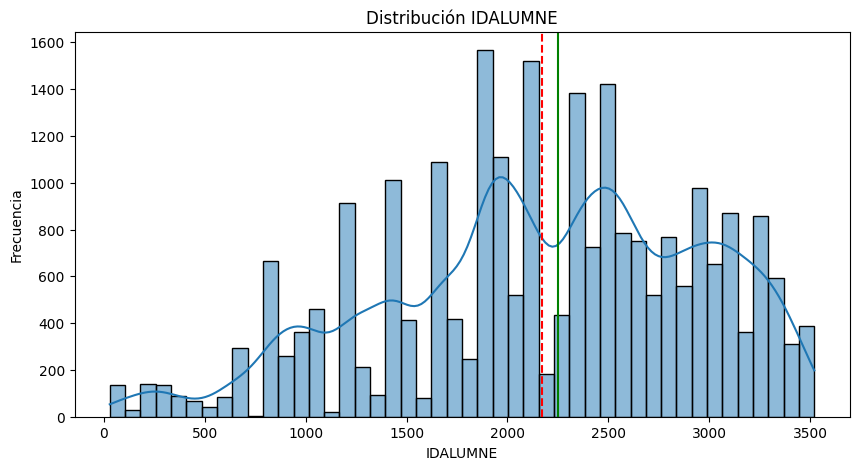

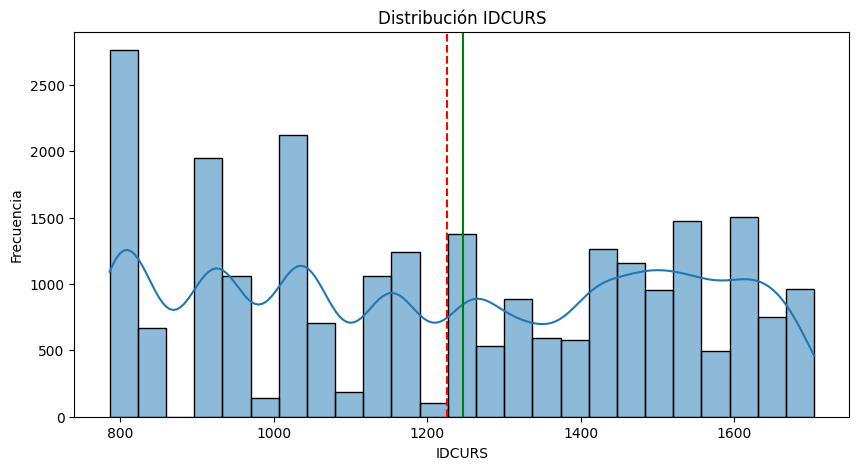

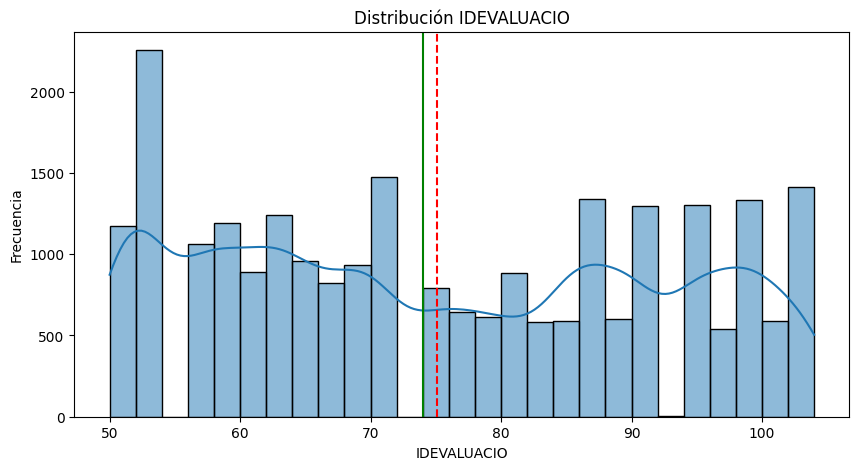

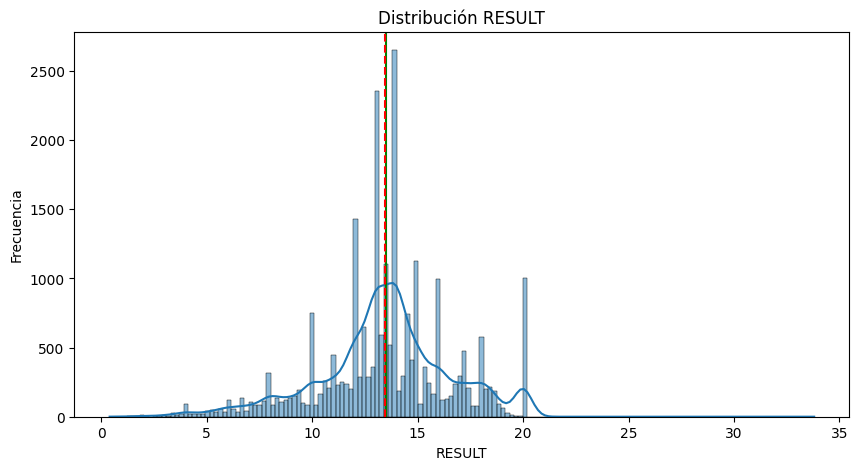

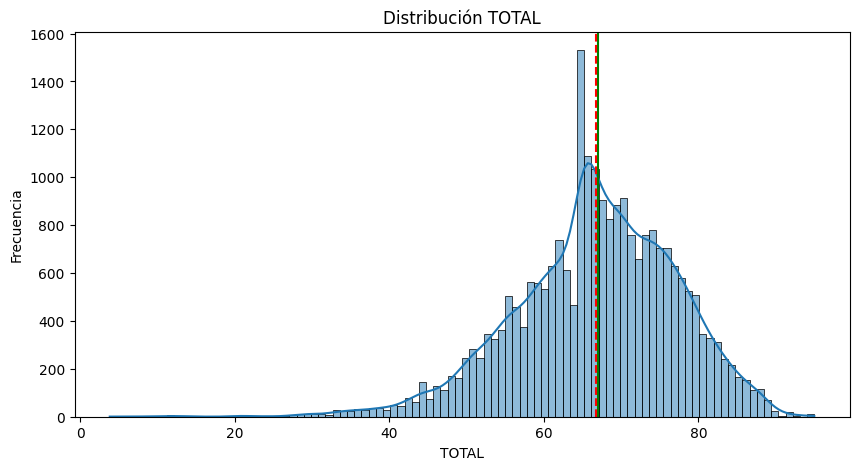

In [20]:
histogramas = auto_visualize_dataframe_histplot(df) 

histogramas

#### 3.2 Visualizacion de datos categoricos

In [21]:
def auto_visualize_dataframe_barplot(df):
    for column in df.columns:

        if (
            pd.api.types.is_string_dtype(df[column])
            or pd.api.types.is_categorical_dtype(df[column])
        ):
            plt.figure(figsize=(10, 5))
            
            ax = df[column].value_counts().head(10).plot(kind="bar")

            plt.title(f"Categorías principales {column}")
            plt.xlabel(column)
            plt.ylabel("Número")
            plt.xticks(rotation=45)

        
            for bar in ax.patches:
                height = bar.get_height()
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    height,
                    f"{int(height)}",
                    ha="center",
                    va="bottom"
                )

            plt.show()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_66260\1905990190.py:6: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  or pd.api.types.is_categorical_dtype(df[column])


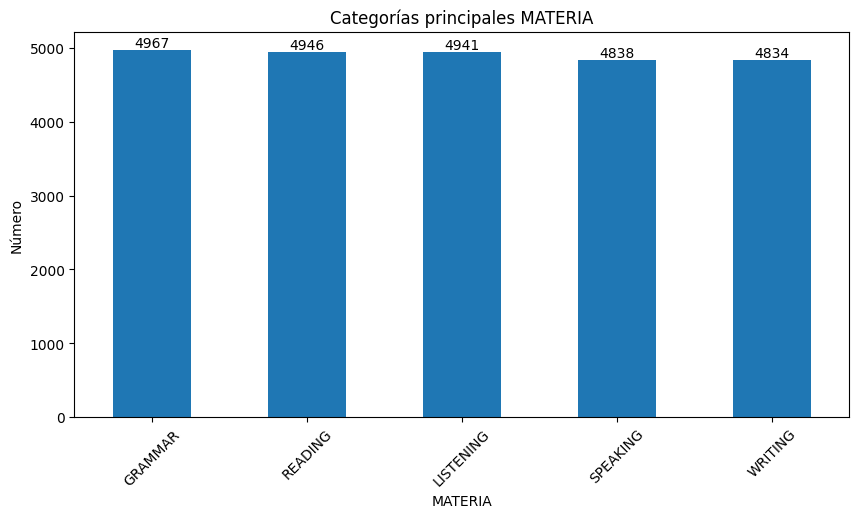

C:\Users\Usuario\AppData\Local\Temp\ipykernel_66260\1905990190.py:6: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  or pd.api.types.is_categorical_dtype(df[column])


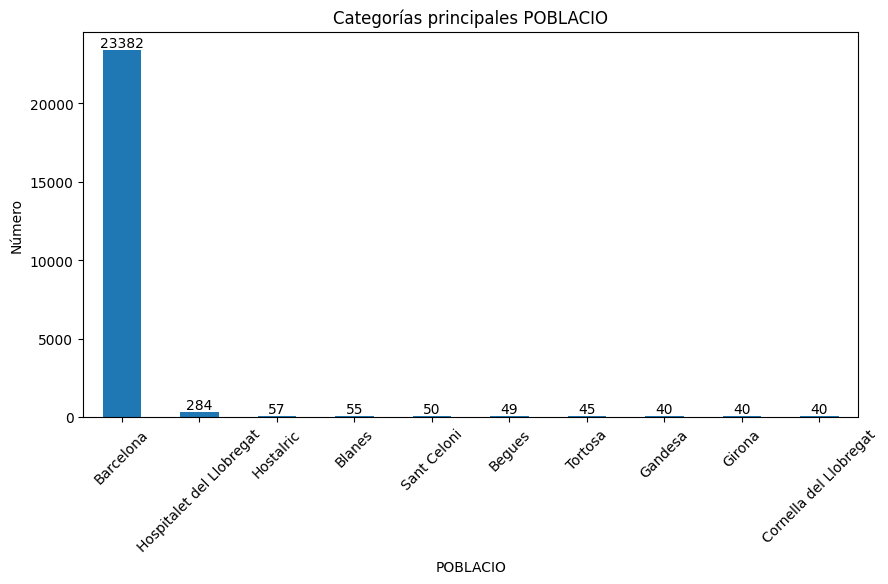

C:\Users\Usuario\AppData\Local\Temp\ipykernel_66260\1905990190.py:6: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  or pd.api.types.is_categorical_dtype(df[column])


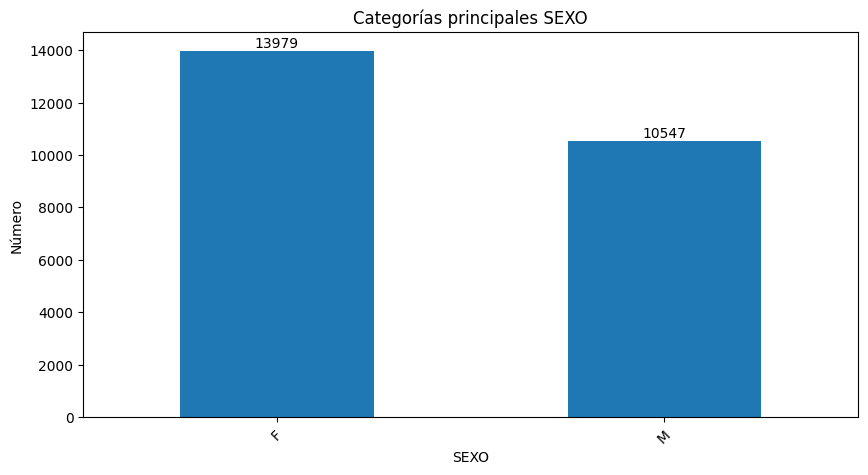

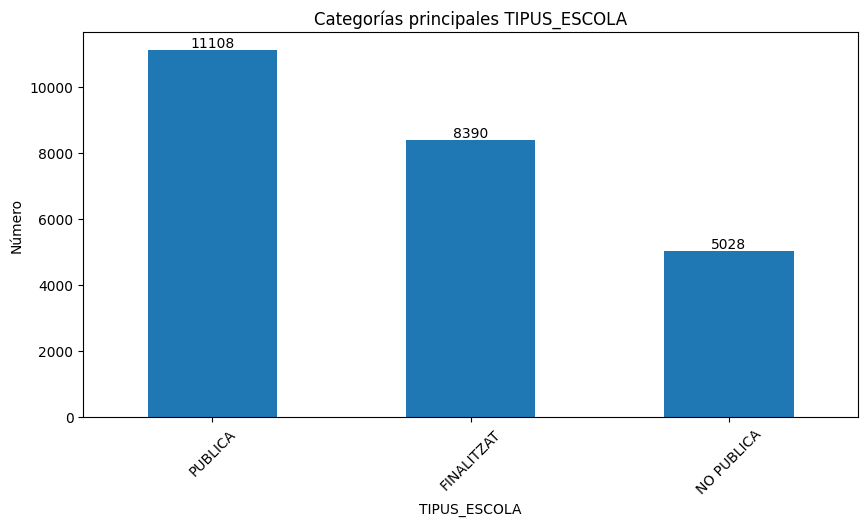

C:\Users\Usuario\AppData\Local\Temp\ipykernel_66260\1905990190.py:6: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  or pd.api.types.is_categorical_dtype(df[column])


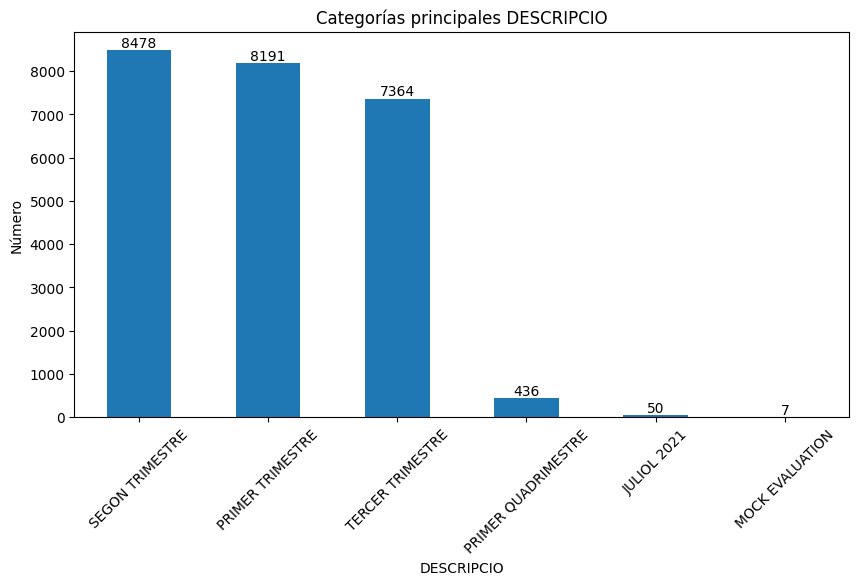

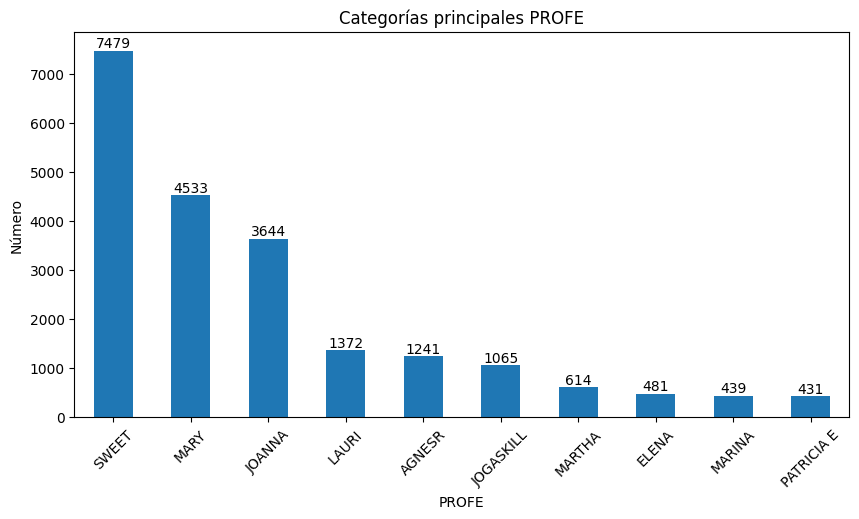

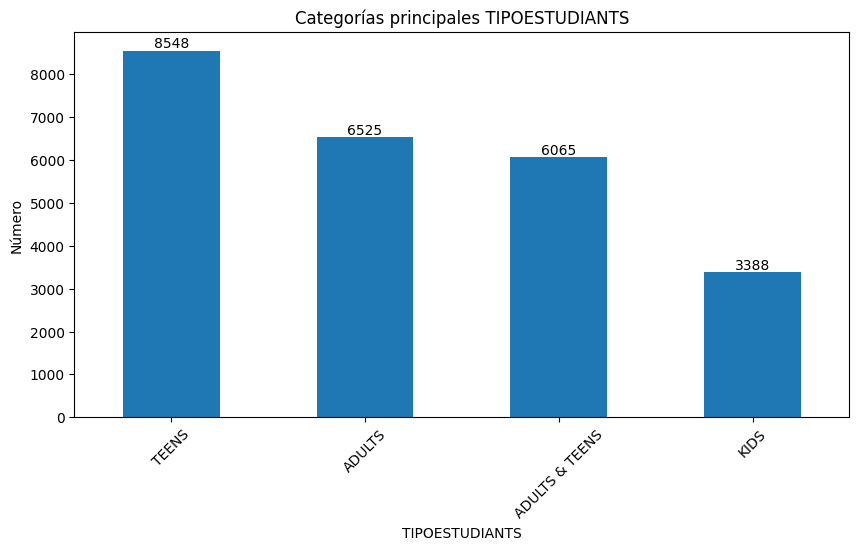

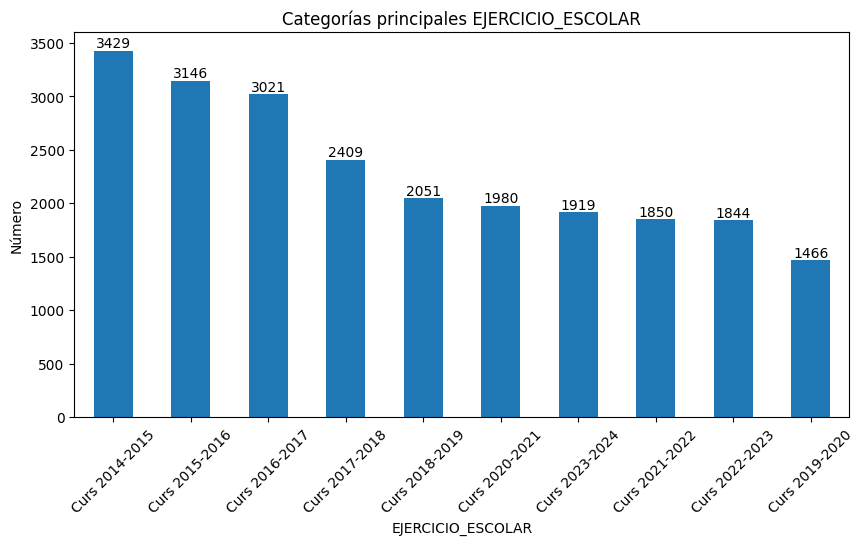

C:\Users\Usuario\AppData\Local\Temp\ipykernel_66260\1905990190.py:6: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  or pd.api.types.is_categorical_dtype(df[column])


In [22]:
bar_plots = auto_visualize_dataframe_barplot(df)

#### 3.3 Valores atípicos estadísticos

In [23]:
numeric_cols = df.select_dtypes(include="number").columns.difference(["id"])
numeric_cols.T

Index(['IDALUMNE', 'IDCURS', 'IDEVALUACIO', 'RESULT', 'TOTAL'], dtype='object')

In [24]:
def auto_visualize_boxplot(df):
    for col in numeric_cols:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=df[col])
        plt.title(f"Boxplot: {col}")
        plt.xlabel(col)
        plt.show()

    if len(numeric_cols) > 1:
        plt.figure(figsize=(10, 8))
        corr = df[numeric_cols].corr()

        sns.heatmap(
            corr,
            annot=True,
            fmt=".2f",
            cmap="GnBu",
            square=True,
            linewidths=0.5
        )

        plt.title("Correlation heatmap")
        plt.show()

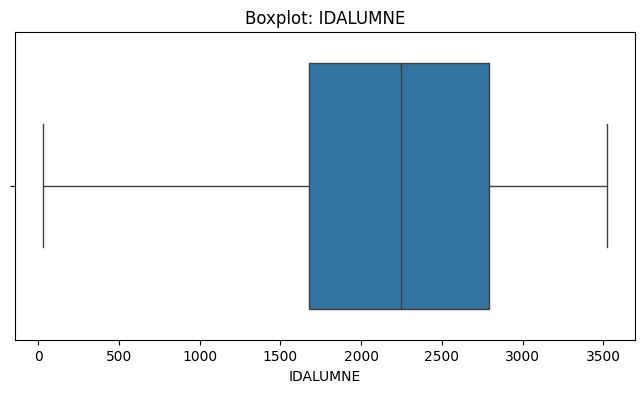

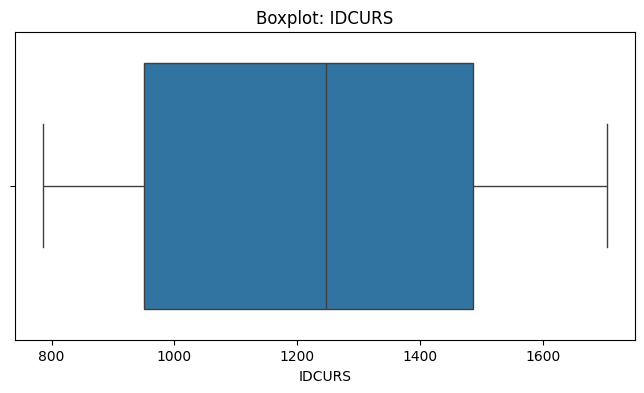

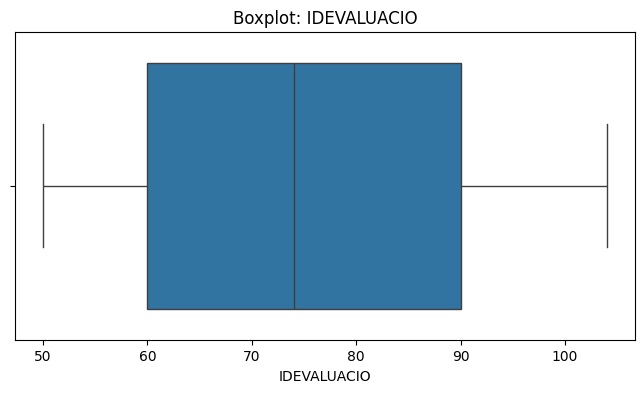

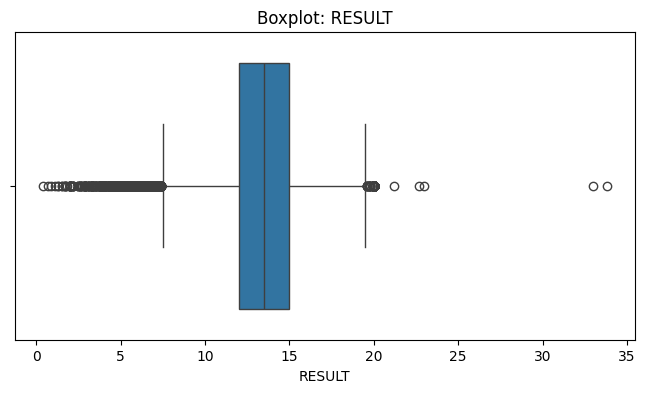

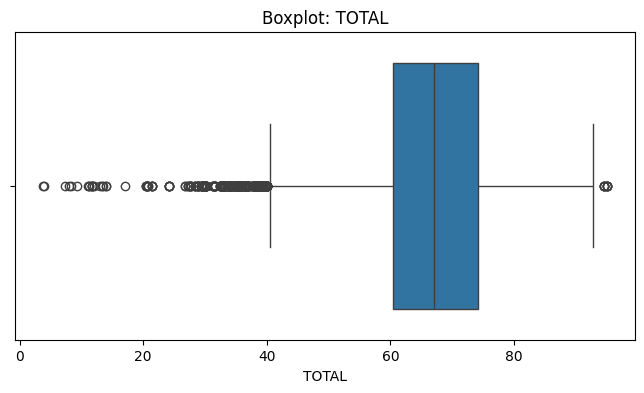

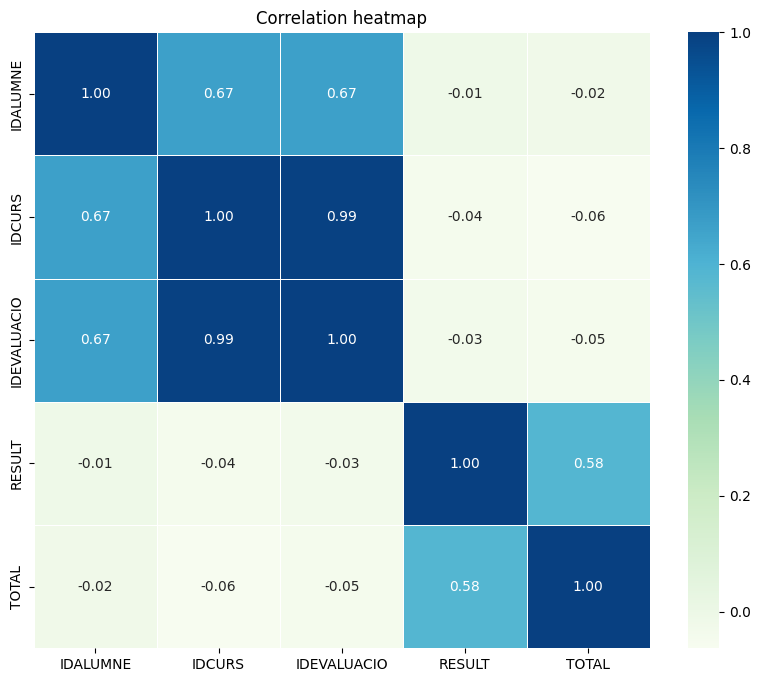

In [25]:
box_plots = auto_visualize_boxplot(df)

## 4. BUSINESS CONTEXT 

#### 4.1 Values numericos asociado con target

Text(0.5, 1.0, 'Violinplot: RESULT')

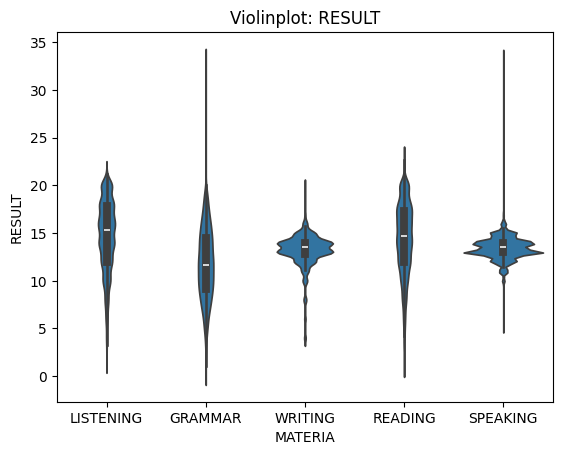

In [26]:
sns.violinplot(x="MATERIA", y="RESULT", data=df)
plt.title(f"Violinplot: RESULT")

Text(0.5, 1.0, 'Violinplot: TOTAL')

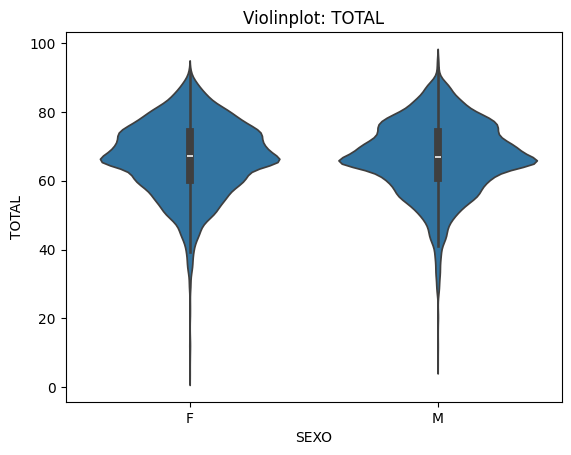

In [27]:
sns.violinplot(x="SEXO", y="TOTAL", data=df)
plt.title(f"Violinplot: TOTAL")

Text(0.5, 1.0, 'Violinplot: TOTAL')

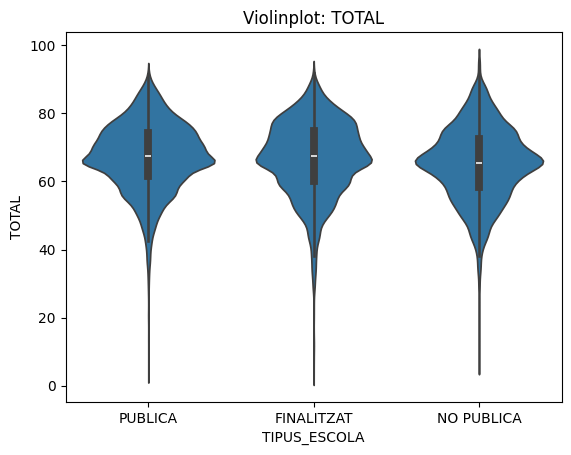

In [28]:
sns.violinplot(x="TIPUS_ESCOLA", y="TOTAL", data=df)
plt.title(f"Violinplot: TOTAL")

Text(0.5, 1.0, 'Violinplot: TIPOESTUDIANTS')

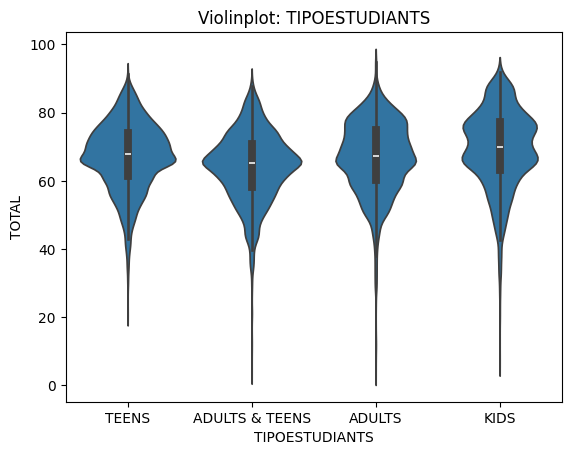

In [29]:
sns.violinplot(x="TIPOESTUDIANTS", y="TOTAL", data=df)
plt.title(f"Violinplot: TIPOESTUDIANTS")

Text(0.5, 1.0, 'Violinplot: PROFE')

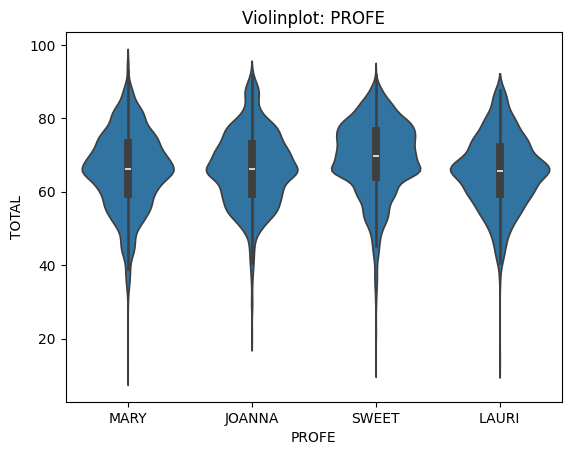

In [30]:
profes = ["MARY", "SWEET", "JOANNA","LAURI"]

df_filtrado = df[df["PROFE"].isin(profes)]

sns.violinplot(x="PROFE", y="TOTAL", data=df_filtrado)
plt.title("Violinplot: PROFE")